# 01 · 모듈 개요 (each file's role)

`po_mdoppler` 패키지의 **각 파일이 무슨 일을 하는지**와 최소 사용법을 보여줍니다.
물리·수치는 `sim_ablation.py` 와 동일(검증됨), 구조만 모듈로 분해했습니다.

| 파일 | 역할 |
|------|------|
| `configs/default.py` | `SimConfig`(레이더/샘플링) + 재질 + airframe 기하 + 경로 |
| `po_sim/mesh.py` | PLY 로드 + body/blade → world 조립 (**매쉬 조립**) |
| `po_sim/kinematics.py` | PX4 CSV → 펄스별 pose + 블레이드각 (**기동**) |
| `po_sim/physics.py` | Fresnel Γ + PO 패싯 산란 (**PO 전용**) |
| `po_sim/occlusion.py` | Embree BVH 레이캐스팅 가시성 |
| `po_sim/engine.py` | 펄스 분해 + 윈도우 루프 + multiprocessing |
| `scripts/generate_ablation.py` | CLI 진입점 |


In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# make the package importable whether run from examples/ or po_mdoppler/
cwd = os.getcwd()
PKG = cwd if os.path.isdir(os.path.join(cwd, "po_sim")) else os.path.dirname(cwd)
if PKG not in sys.path:
    sys.path.insert(0, PKG)
print("package root:", PKG)
from configs.default import (
    SimConfig, MESH_DIR, DATA_BASE,
    BODY_MAT, BLADE_MATS, BLADE_MAT_KEYS, BLADE_OFFSETS, BLADE_DIRS,
)
from po_sim import mesh, physics, kinematics
print("imported configs.default + po_sim.{mesh, physics, kinematics}")

package root: /workspace/sionna_sim/po_mdoppler


imported configs.default + po_sim.{mesh, physics, kinematics}


## `configs/default.py` — 파라미터
`SimConfig` 는 레이더/샘플링 스칼라이고, 파생값(λ, k, 윈도우 길이)은 property 입니다.

In [2]:
cfg = SimConfig()
print("f_c = %.3f GHz | lambda = %.2f mm | k = %.2f rad/m" % (cfg.f_c/1e9, cfg.wavelength*1000, cfg.k))
print("PRF = %d Hz | dt = %.2f us | N_pulses = %d | window = %.1f ms"
      % (cfg.prf, cfg.dt_radar*1e6, cfg.n_pulses, cfg.window_duration*1000))
print("radar offset: range %.0f m, height %.0f m, azimuth %.0f deg"
      % (cfg.radar_range_offset, cfg.radar_height_offset, cfg.radar_azimuth_deg))
print("rpm_scale =", cfg.rpm_scale, "| bvh_rebuild_every =", cfg.bvh_rebuild_every)
print()
print("body (er, sigma):", BODY_MAT)
for k in BLADE_MAT_KEYS:
    print("  blade %-6s (er, sigma): %s" % (k, BLADE_MATS[k]))
print("blade offsets [m]:\n", np.round(BLADE_OFFSETS, 4))
print("blade spin dirs:", BLADE_DIRS)

f_c = 9.850 GHz | lambda = 30.46 mm | k = 206.30 rad/m
PRF = 35000 Hz | dt = 28.57 us | N_pulses = 5000 | window = 142.9 ms
radar offset: range 60 m, height 20 m, azimuth 0 deg
rpm_scale = 6.0 | bvh_rebuild_every = 100

body (er, sigma): (1.0, 1000000.0)
  blade nylon  (er, sigma): (4.0, 0.0)
  blade cf     (er, sigma): (8.0, 12.0)
  blade metal  (er, sigma): (1.0, 1000000.0)
blade offsets [m]:
 [[-0.1237  0.1237  0.072 ]
 [ 0.1237 -0.1237  0.072 ]
 [ 0.1237  0.1237  0.072 ]
 [-0.1237 -0.1237  0.072 ]]
blade spin dirs: [-1 -1  1  1]


## `po_sim/mesh.py` — 매쉬 조립
`DroneMesh` 는 메쉬를 한 번 로드하고 펄스마다 world-frame 패싯(중심/법선/면적)을 만듭니다.

In [3]:
dm = mesh.DroneMesh.load(MESH_DIR)
print("total tris / pulse:", dm.total_tris)
print("body faces:", dm.body_f.shape[0], "| blades:", dm.n_blades, "x %d faces" % dm.blade_f_list[0].shape[0])

centers, normals, areas = dm.body_facets(np.eye(3), np.zeros(3))   # identity pose
print("body_facets -> centers", centers.shape, "normals", normals.shape, "areas", areas.shape)
print("mean facet area = %.3e m^2 | total body area = %.4f m^2" % (areas.mean(), areas.sum()))

total tris / pulse: 31446
body faces: 30166 | blades: 4 x 320 faces
body_facets -> centers (30166, 3) normals (30166, 3) areas (30166,)
mean facet area = 7.162e-06 m^2 | total body area = 0.2160 m^2


## `po_sim/kinematics.py` — 기동
PX4 텔레메트리를 로드해 펄스별 (위치·자세·블레이드각) 을 만들고, 레이더 위치를 계산합니다.

In [4]:
flight = kinematics.load_flight(os.path.join(DATA_BASE, "grade_2"), cfg)
radar_pos = kinematics.radar_position(flight.flight_center, cfg)
starts = kinematics.window_starts(flight, cfg)
print("usable to t = %.1f s | flight centre = %s" % (flight.t_max, np.round(flight.flight_center, 2)))
print("radar =", np.round(radar_pos, 2), "| slant range = %.1f m" % np.linalg.norm(flight.flight_center - radar_pos))
print("non-overlapping windows:", len(starts))
positions, rot_matrices, blade_angles = kinematics.window_poses(flight, starts[0], cfg)
print("window_poses[0] -> positions", positions.shape, "| rot_matrices", rot_matrices.shape, "| blade_angles", blade_angles.shape)

usable to t = 86.6 s | flight centre = [32.21 -0.57 10.46]
radar = [ 32.21 -60.57  -9.54] | slant range = 63.2 m
non-overlapping windows: 571
window_poses[0] -> positions (5000, 3) | rot_matrices (5000, 3, 3) | blade_angles (5000, 4)


## `po_sim/physics.py` — PO 산란 (Fresnel Γ)
입사각별 반사계수. 도체(body/metal)는 |Γ|~1, 유전체(blade)는 각도 의존.

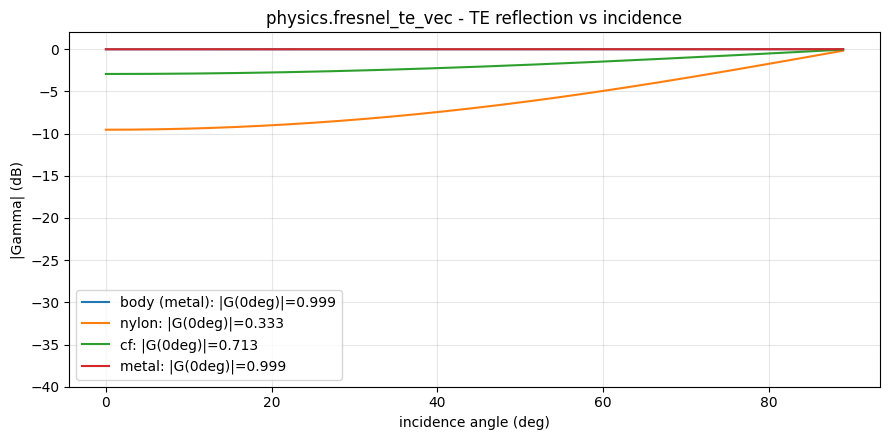

In [5]:
theta = np.linspace(0, 89, 200)
cos_t = np.cos(np.deg2rad(theta))
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, (er, sg) in [("body (metal)", BODY_MAT)] + [(k, BLADE_MATS[k]) for k in BLADE_MAT_KEYS]:
    g = np.abs(physics.fresnel_te_vec(cos_t, er, sg, cfg.f_c))
    ax.plot(theta, 20*np.log10(g + 1e-30), label="%s: |G(0deg)|=%.3f" % (name, g[0]))
ax.set_xlabel("incidence angle (deg)"); ax.set_ylabel("|Gamma| (dB)")
ax.set_title("physics.fresnel_te_vec - TE reflection vs incidence")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-40, 2)
plt.tight_layout(); plt.show()

## `po_sim/occlusion.py` + `engine.py` — 가시성/차폐 + 한 펄스
BVH를 만들고 한 펄스를 분해 계산합니다. 전체 생성은 CLI 로.

In [6]:
from po_sim import occlusion
from po_sim.engine import SceneSpec, compute_pulse_decomposed, signal_keys

spec = SceneSpec(BODY_MAT, dict(BLADE_MATS), list(BLADE_MAT_KEYS), BLADE_OFFSETS, BLADE_DIRS)
R0, p0, ba0 = rot_matrices[0], positions[0], blade_angles[0]
bvh = occlusion.build_body_bvh(dm, R0, p0)
out = compute_pulse_decomposed(dm, cfg, spec, R0, p0, ba0, radar_pos, bvh)
print("keys/window:", signal_keys(BLADE_MAT_KEYS))
print("\none-pulse decomposed contributions:")
for k, v in out.items():
    print("  %-18s |.| = %.3e" % (k, abs(v)))
print("\n-> full run:  python scripts/generate_ablation.py --grade 2 ...")

keys/window: ['body_none', 'body_occ', 'blade_none_nylon', 'blade_none_cf', 'blade_none_metal', 'blade_occ_nylon', 'blade_occ_cf', 'blade_occ_metal']

one-pulse decomposed contributions:
  body_none          |.| = 5.013e-07
  body_occ           |.| = 2.298e-07
  blade_none_nylon   |.| = 3.837e-08
  blade_none_cf      |.| = 5.178e-08
  blade_none_metal   |.| = 6.500e-08
  blade_occ_nylon    |.| = 2.608e-08
  blade_occ_cf       |.| = 4.019e-08
  blade_occ_metal    |.| = 5.194e-08

-> full run:  python scripts/generate_ablation.py --grade 2 ...


---
**요약** — 파이프라인: `kinematics`(기동) → `mesh`(조립) → `physics`+`occlusion`(산란/가시성) → `engine`(분해·윈도우).
다음: `02_mesh_and_motion.ipynb`(메쉬·회전 시각화), `03_normals_and_occlusion.ipynb`(법선·차폐 시각화).